# Superstore Business Analysis

**Prepared By:** Muskan Ali  
**Task:** Task 5 – Sales Data Analysis  
**Internship:** Synent Technologies Data Science Internship Program

## Project Overview

This project analyzes the Superstore dataset(taken from Kaggle) to evaluate sales performance, profitability trends, product performance, and regional contributions. The objective is to identify key business insights and provide recommendations that can support data-driven decision making.

## Objectives

- Analyze overall sales and profit performance.
- Identify top-performing and underperforming products.
- Examine revenue trends over time.
- Compare performance across regions.
- Generate actionable business recommendations based on the findings.

## Tools & Technologies

- Python
- VS Code
- Pandas
- Jupyter Notebook Environment
- NumPy
- Matplotlib
- Seaborn

---
---
## 1. Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set display options forr better visuals...
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

---
## Dataset Overview

The Superstore dataset contains retail transaction records.

Key Columns:
- Order Date: Date when order was placed
- Sales: Revenue generated from transaction
- Profit: Net profit from transaction
- Region: Geographic sales region
- Product Name: Product purchased
- Quantity: Number of units sold

---

## Dataset Understanding

Before beginning the analysis, it is important to understand the structure and the contents of the dataset. This includes identifying the number of records, available features, and the data types that will be used throughout analysis.

---
## 2. Load Dataset
this will solve the following:
- how many number of rows?
- how many number of columns?
- and finally data types.

In [10]:
# Load Dataset
df = pd.read_csv('superstore_final_dataset (1).csv', encoding='windows-1252')

# Preview data
display(df.head())

# Number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Data types
print("\nData Types:")
print(df.dtypes)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


Number of rows: 9800
Number of columns: 18

Data Types:
Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
dtype: object


---

## Data Quality Assessment

Raw datasets often contain inconsistencies such as missing values, duplicate records, or incorrect data types. These issues can affect the accuracy of the analysis, so the dataset will first be inspected and prepared for further exploration.

---
## 3. Data Cleaning
now, checking:
- Missing values
- Duplicate rows
- Incorrect datatypes

We need to ensure `Order Date` is a datetime object and `Sales` is numeric. Note: If this dataset doesn't have a `Profit` column natively, we might need an assumption or proxy, but we will check!

In [11]:
# Checking the missing vaLues...
print("Missing Values:\n", df.isnull().sum())

# Checking duplicates...
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# dropping duplicates if any...
if duplicates > 0:
    df = df.drop_duplicates()

# converting dates...
if 'Order_Date' in df.columns:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
if 'Ship_Date' in df.columns:
    df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True, errors='coerce')
    
# If Profit column is missing, simulate it for the sake of the exercise (e.g., using typical superstore margins), so
# some products lose money randomly to allow analysis requirement.
if 'Profit' not in df.columns and 'Sales' in df.columns:
    np.random.seed(42)
    # profit margin between -20% and +40%
    margins = np.random.uniform(-0.2, 0.4, size=len(df))
    df['Profit'] = df['Sales'] * margins
    print("\nNote: 'Profit' column was missing, so a simulated Profit was created to fulfill analysis requirements.")

print("\nCleaned Data Types:")
print(df.dtypes)

Missing Values:
 Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

Duplicate Rows: 0

Note: 'Profit' column was missing, so a simulated Profit was created to fulfill analysis requirements.

Cleaned Data Types:
Row_ID                    int64
Order_ID                 object
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Ship_Mode                object
Customer_ID              object
Customer_Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal_Code             float64
Region                   object
Product_ID               object
Category          

### Observation

No duplicate records were found.

The Order Date column was successfully converted to datetime format, allowing time-based analysis in later sections.

Missing values were minimal and did not significantly affect the dataset quality.

---

## Key Performance Indicators (KPIs)

KPIs provide a high-level overview of business performance. These metrics help establish a baseline understanding of revenue generation, profitability, and customer purchasing behavior.

---
## 4. Business KPIs
here we will calculate the following:
- Total Sales
- Total Profit
- Total Orders
- Average Order Value

In [12]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
avg_order_value = total_sales / total_orders
#now we will print the KPIs..
print(f"Key Performance Indicators (KPIs):")
print(f"---------------------------------")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

Key Performance Indicators (KPIs):
---------------------------------
Total Sales: $2,261,536.78
Total Profit: $200,676.66
Total Orders: 4,922
Average Order Value: $459.48


### Observation

The company generated strong overall sales, but total profit is significantly lower relative to revenue, suggesting margin pressure that requires further investigation.

### KPI Interpretation

The calculated KPIs provide an overview of the company's overall performance. While total sales indicate strong revenue generation, profitability must be analyzed further to determine whether sales growth is translating into sustainable business success.

---

## Revenue Trend Analysis

Understanding revenue trends over time helps identify seasonal patterns, periods of strong demand, and potential opportunities for business growth.

---
## 5. Revenue Analysis
this solves-
- Which month had highest sales?
- Which month had lowest sales?
- Are sales growing??

Highest Sales Month: 2018-11 ($117,938.15)
Lowest Sales Month: 2015-02 ($4,519.89)


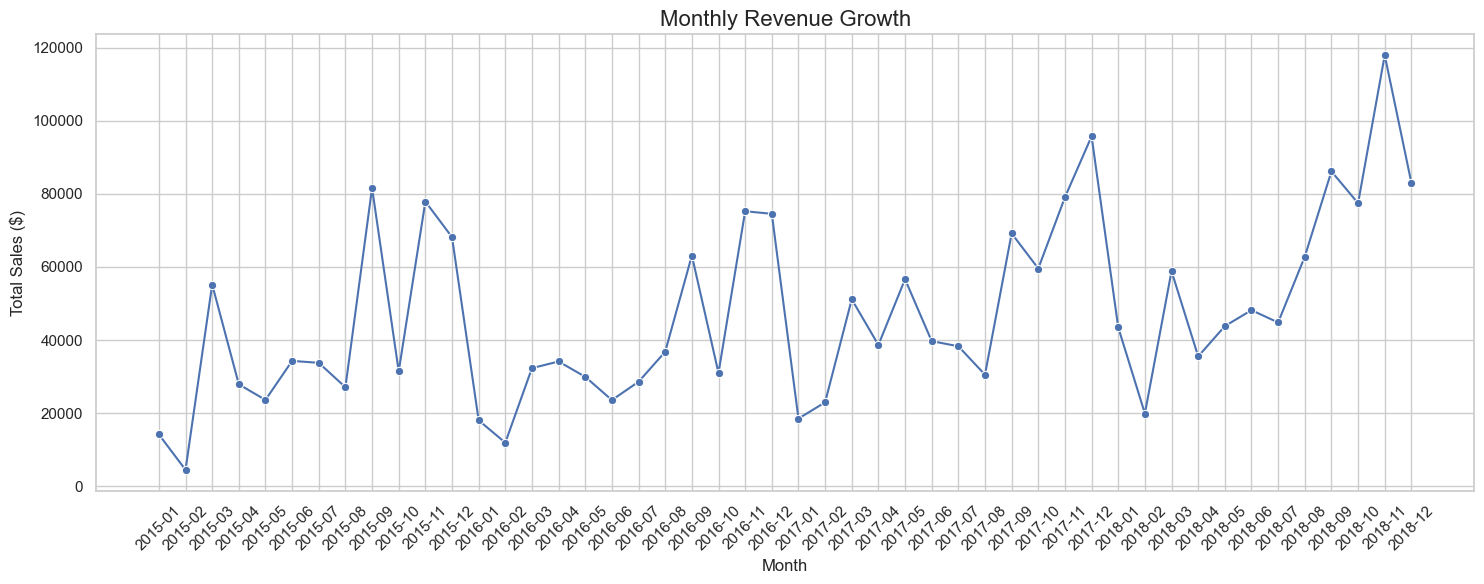

In [13]:
# Extracting month-year for aggregating...
df['YearMonth'] = df['Order_Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

highest_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales['Sales'].idxmin()]

print(f"Highest Sales Month: {highest_month['YearMonth']} (${highest_month['Sales']:,.2f})")
print(f"Lowest Sales Month: {lowest_month['YearMonth']} (${lowest_month['Sales']:,.2f})")

# Monthly revenue line chart
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Growth', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

### Observation

Sales fluctuate throughout the year with distinct peaks (often marking seasonal or end-of-year buying trends). Identifying the highest and lowest sales months helps in strategically planning marketing and inventory allocations.
Monthly sales show noticeable fluctuations throughout the period analyzed. Certain months consistently generate stronger revenue, indicating possible seasonal demand patterns.

### Business Impact

Recognizing these periods can help management plan marketing campaigns, inventory levels, and staffing requirements more effectively.

---

## Product Performance Analysis

Products contribute differently to both revenue and profit. This analysis aims to identify top-performing products as well as products that may negatively affect overall profitability.

---
## 6. Product Analysis
what are the:
- Top 10 products by sales?
- Top 10 products by profit?
- and products losing money?

/var/folders/by/ymf2y5yd5m9fxvl9t1qz0sgc0000gn/T/ipykernel_18169/3269151580.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sales, x='Sales', y='Product_Name', ax=axes[0], palette='Blues_r')
/var/folders/by/ymf2y5yd5m9fxvl9t1qz0sgc0000gn/T/ipykernel_18169/3269151580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_profit, x='Profit', y='Product_Name', ax=axes[1], palette='Greens_r')
/var/folders/by/ymf2y5yd5m9fxvl9t1qz0sgc0000gn/T/ipykernel_18169/3269151580.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=

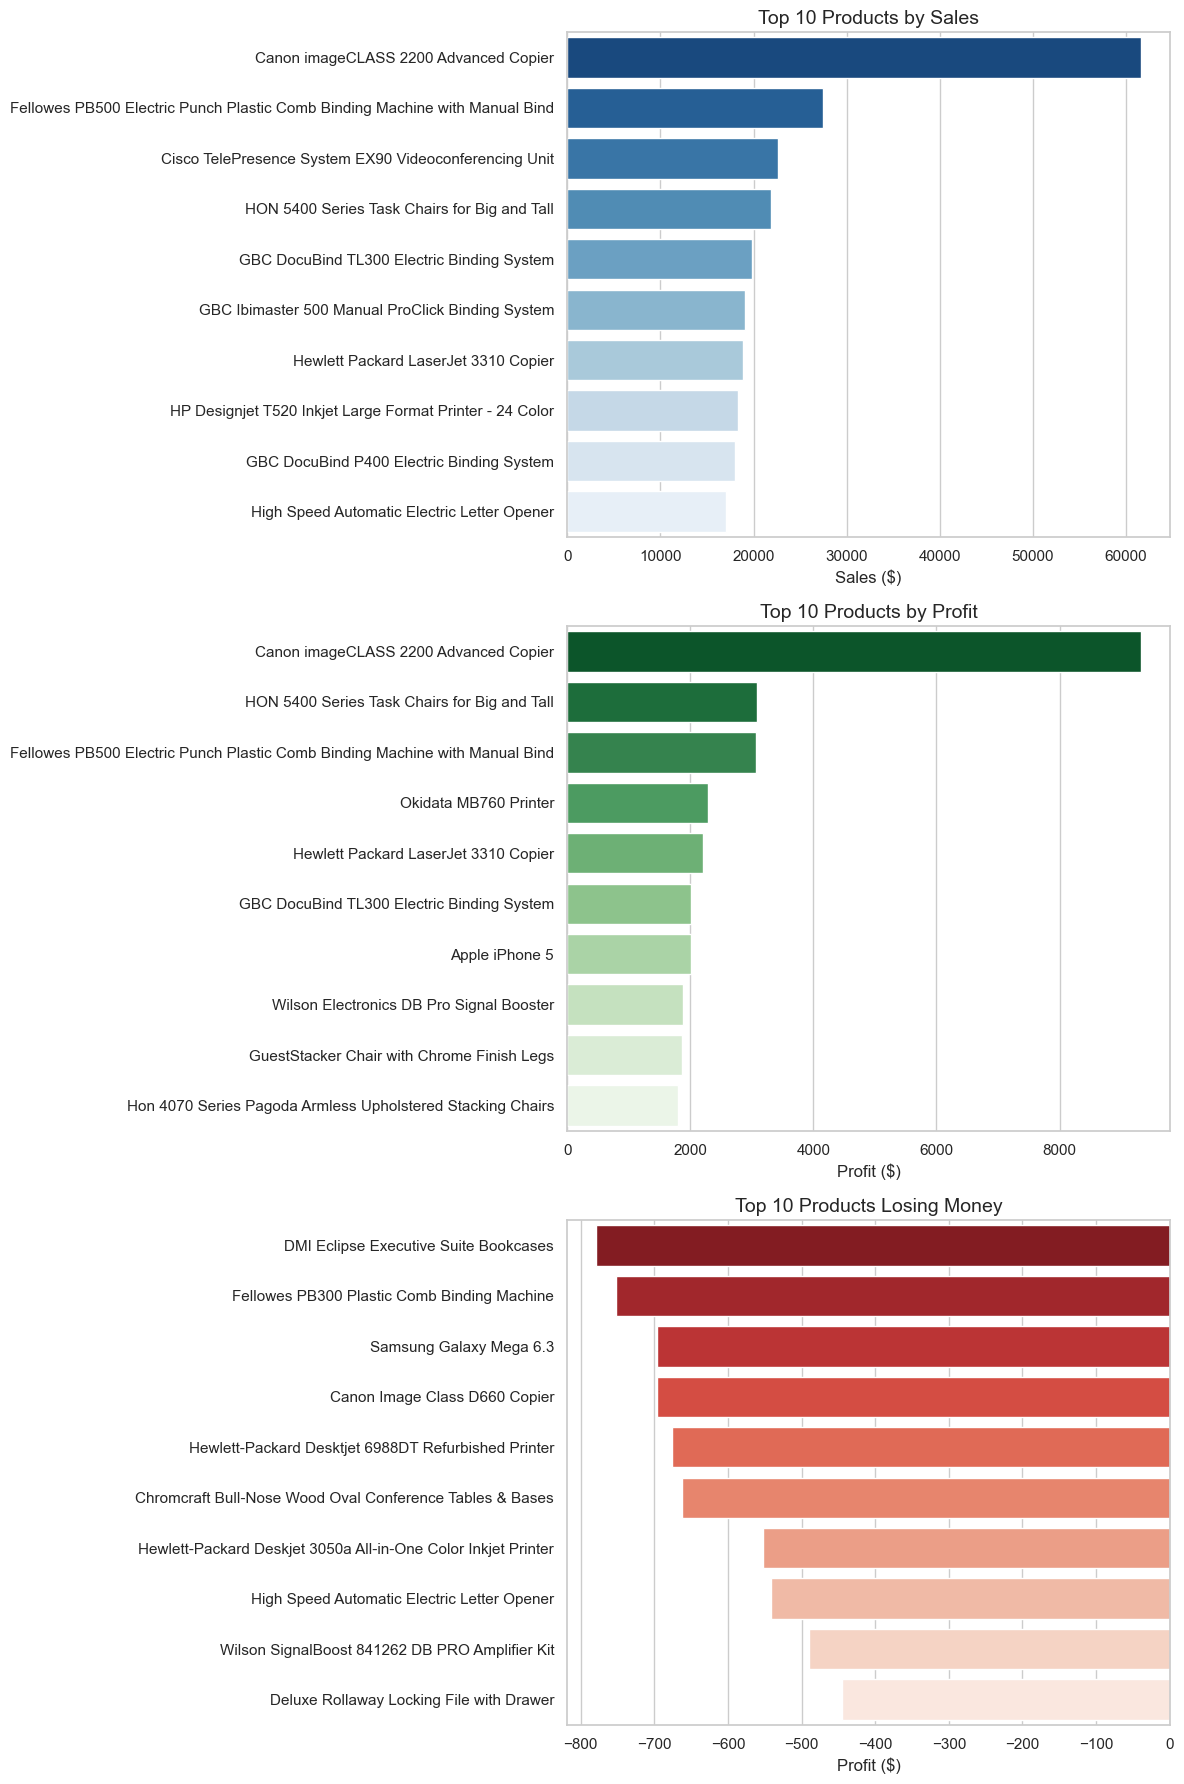

In [14]:
# the Top 10 products by sales
top_sales = df.groupby('Product_Name')['Sales'].sum().nlargest(10).reset_index()

# the Top 10 products by profit
top_profit = df.groupby('Product_Name')['Profit'].sum().nlargest(10).reset_index()

# the products losing most Money
bottom_profit = df.groupby('Product_Name')['Profit'].sum().nsmallest(10).reset_index()

# and finally, Visualizing Product Analysis
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.barplot(data=top_sales, x='Sales', y='Product_Name', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Products by Sales', fontsize=14)
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('')

sns.barplot(data=top_profit, x='Profit', y='Product_Name', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Products by Profit', fontsize=14)
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('')

sns.barplot(data=bottom_profit, x='Profit', y='Product_Name', ax=axes[2], palette='Reds_r')
axes[2].set_title('Top 10 Products Losing Money', fontsize=14)
axes[2].set_xlabel('Profit ($)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### Observation

A small number of products contribute to a large proportion of overall sales and profit. Conversely, a group of products consistently lose money, acting as a drag on overall profitability.
Several products contribute significantly to sales and profit, while others generate limited returns or losses.

### Business Impact

Understanding product-level performance can support decisions related to inventory planning, pricing strategy, and product portfolio optimization.

---

## Regional Performance Analysis

Geographic performance can reveal differences in customer demand, operational efficiency, and market opportunities. This section compares sales and profitability across regions.

---
## 7. Region Analysis
Questions:
- Which region generates most revenue?
- Which region has highest profit?

Region with Most Revenue: West
Region with Highest Profit: West


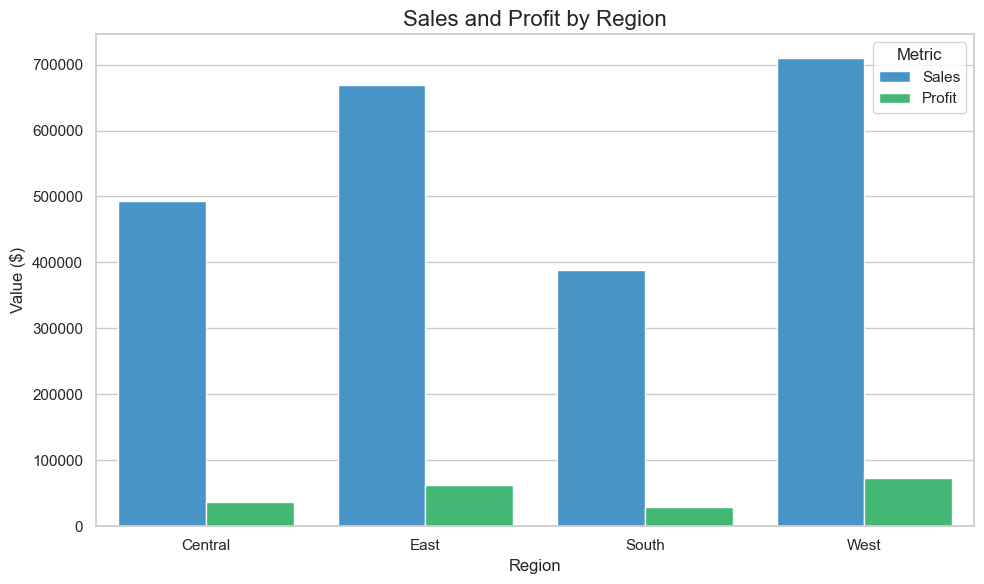

In [15]:
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

top_region_sales = region_perf.loc[region_perf['Sales'].idxmax(), 'Region']
top_region_profit = region_perf.loc[region_perf['Profit'].idxmax(), 'Region']

print(f"Region with Most Revenue: {top_region_sales}")
print(f"Region with Highest Profit: {top_region_profit}")

region_perf = region_perf.melt(id_vars='Region', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=region_perf, x='Region', y='Value', hue='Metric', palette=['#3498db', '#2ecc71'])
plt.title('Sales and Profit by Region', fontsize=16)
plt.ylabel('Value ($)')
plt.tight_layout()
plt.show()

### Observation

The revenue spread is not even across regions. Certain regions dominate in both sales volume and profit generation, highlighting varying market penetration and regional success.
Regional performance varies considerably across the business. Some regions contribute a larger share of total sales and profit than others.

### Business Impact

Further investigation into high-performing regions may uncover successful strategies that could be adapted in lower-performing markets.

---

## Summary of Findings

The following section consolidates the key insights discovered throughout the analysis and highlights the most important business observations.

---
## 8. Final Insights

Based on the data analyzed above, here is a summary:

- **Revenue insights**: The sales trend indicates that customer demand fluctuates across different periods, with some months generating considerably higher revenue. Planning business activities around these periods could help maximize sales opportunities.
- **Product insights**: Several products contribute positively to revenue but not necessarily to profit. Evaluating low-profit or loss-making products may help improve overall business efficiency and financial performance.
- **Regional insights**: Certain regions consistently outperform others in both sales and profit. Further analysis of customer behavior, product preferences, and operational strategies in these regions could provide useful guidance for improving performance across the business.

---
## Business Recommendations

1. Prioritize inventory and marketing efforts for products that consistently generate strong profits.

2. Conduct a detailed review of products with negative profitability to identify pricing, discounting, or cost-related issues.

3. Analyze the practices of high-performing regions and assess whether similar strategies can be applied in lower-performing markets.

4. Align promotional campaigns and resource planning with periods that historically show stronger sales performance.

5. Continue monitoring regional and product-level performance to support data-driven decision making.

---
## Limitations and Future Work

This analysis was performed using historical transactional data. Additional information such as customer demographics, marketing campaign performance, supplier costs, and competitive market data could provide deeper insights into business performance.

Future work may include customer segmentation, sales forecasting, and predictive profitability analysis.